# Prepare the data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [4]:
record=pd.read_csv("Record.csv")
client=pd.read_csv("Client.csv")

In [6]:
print(record.head())
print(client.head())

   rev_Mean  mou_Mean  totmrc_Mean  da_Mean  ovrmou_Mean  ovrrev_Mean  \
0   23.9975    219.25       22.500   0.2475         0.00          0.0   
1   57.4925    482.75       37.425   0.2475        22.75          9.1   
2   16.9900     10.25       16.990   0.0000         0.00          0.0   
3   38.0000      7.50       38.000   0.0000         0.00          0.0   
4   55.2300    570.50       71.980   0.0000         0.00          0.0   

   vceovr_Mean  datovr_Mean  roam_Mean  change_mou  ...  mou_opkv_Mean  \
0          0.0          0.0        0.0     -157.25  ...      55.220000   
1          9.1          0.0        0.0      532.25  ...     169.343333   
2          0.0          0.0        0.0       -4.25  ...       0.233333   
3          0.0          0.0        0.0       -1.50  ...       5.450000   
4          0.0          0.0        0.0       38.50  ...     218.086667   

   mou_opkd_Mean  drop_blk_Mean  attempt_Mean  complete_Mean  callfwdv_Mean  \
0            0.0       1.333333     5

In [8]:
full_data=pd.merge(record,client,on="Customer_ID")

In [10]:
full_data.head()

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,...,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,...,O,0.0,I,U,U,U,U,U,Y,434.0


* Data completely

In [11]:
full_data.drop("Customer_ID",axis=1,inplace=True)

# Correlation between features

### First assumbtion
- There are 100 features so we nust delete high correlation (more than 80%)

In [13]:
full_data.shape

(100000, 99)

In [12]:
num_cols_corr=full_data.select_dtypes(include="number").columns
num_data_corr=full_data.loc[:,num_cols_corr]
corr_matrix=num_data_corr.corr()
corr_matrix

,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,phones,models,truck,rv,lor,adults,income,numbcars,forgntvl,eqpdays
rev_Mean,1.000000,0.706029,0.602148,0.403806,0.772117,0.776647,0.772159,0.152664,0.374718,0.075835,...,0.228117,0.225320,-0.035863,-0.010322,-0.056251,-0.033564,-0.040699,0.001509,-0.038434,-0.213402
mou_Mean,0.706029,1.000000,0.575567,0.394583,0.575611,0.541250,0.539811,0.090349,0.125442,-0.008211,...,0.291907,0.286538,-0.054795,-0.027519,-0.063562,-0.023166,-0.093709,0.013006,-0.051355,-0.315322
totmrc_Mean,0.602148,0.575567,1.000000,0.306966,0.200732,0.164401,0.163038,0.035428,0.046865,-0.020845,...,0.223322,0.219285,-0.035703,-0.016609,-0.053149,-0.034945,-0.026211,0.004181,-0.034726,-0.247781
da_Mean,0.403806,0.394583,0.306966,1.000000,0.304596,0.274344,0.274162,0.040290,0.044899,-0.021603,...,0.168919,0.160514,-0.032306,-0.007566,-0.042996,-0.037116,0.032336,-0.000643,-0.021007,-0.120649
ovrmou_Mean,0.772117,0.575611,0.200732,0.304596,1.000000,0.956056,0.953231,0.162933,0.040371,-0.011172,...,0.141164,0.140901,-0.024408,-0.003892,-0.037157,-0.020575,-0.030198,-0.000350,-0.026663,-0.127763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
adults,-0.033564,-0.023166,-0.034945,-0.037116,-0.020575,-0.021399,-0.021327,-0.003055,-0.001428,-0.002512,...,-0.001800,0.002282,0.260806,0.162654,0.366560,1.000000,0.089325,0.237031,0.112912,0.011267
income,-0.040699,-0.093709,-0.026211,0.032336,-0.030198,-0.038617,-0.037516,-0.015531,-0.008839,-0.008239,...,-0.047666,-0.043265,0.037975,0.086854,0.068491,0.089325,1.000000,0.069197,0.088237,0.105680
numbcars,0.001509,0.013006,0.004181,-0.000643,-0.000350,-0.000347,0.000074,-0.004351,-0.005464,0.000997,...,0.006111,0.013237,0.027228,0.014937,0.113999,0.237031,0.069197,1.000000,0.025110,-0.019281
forgntvl,-0.038434,-0.051355,-0.034726,-0.021007,-0.026663,-0.028010,-0.028211,-0.001937,-0.005337,0.005273,...,-0.009672,-0.010085,0.040533,0.046756,0.072458,0.112912,0.088237,0.025110,1.000000,0.046153


In [15]:
import seaborn as sns 

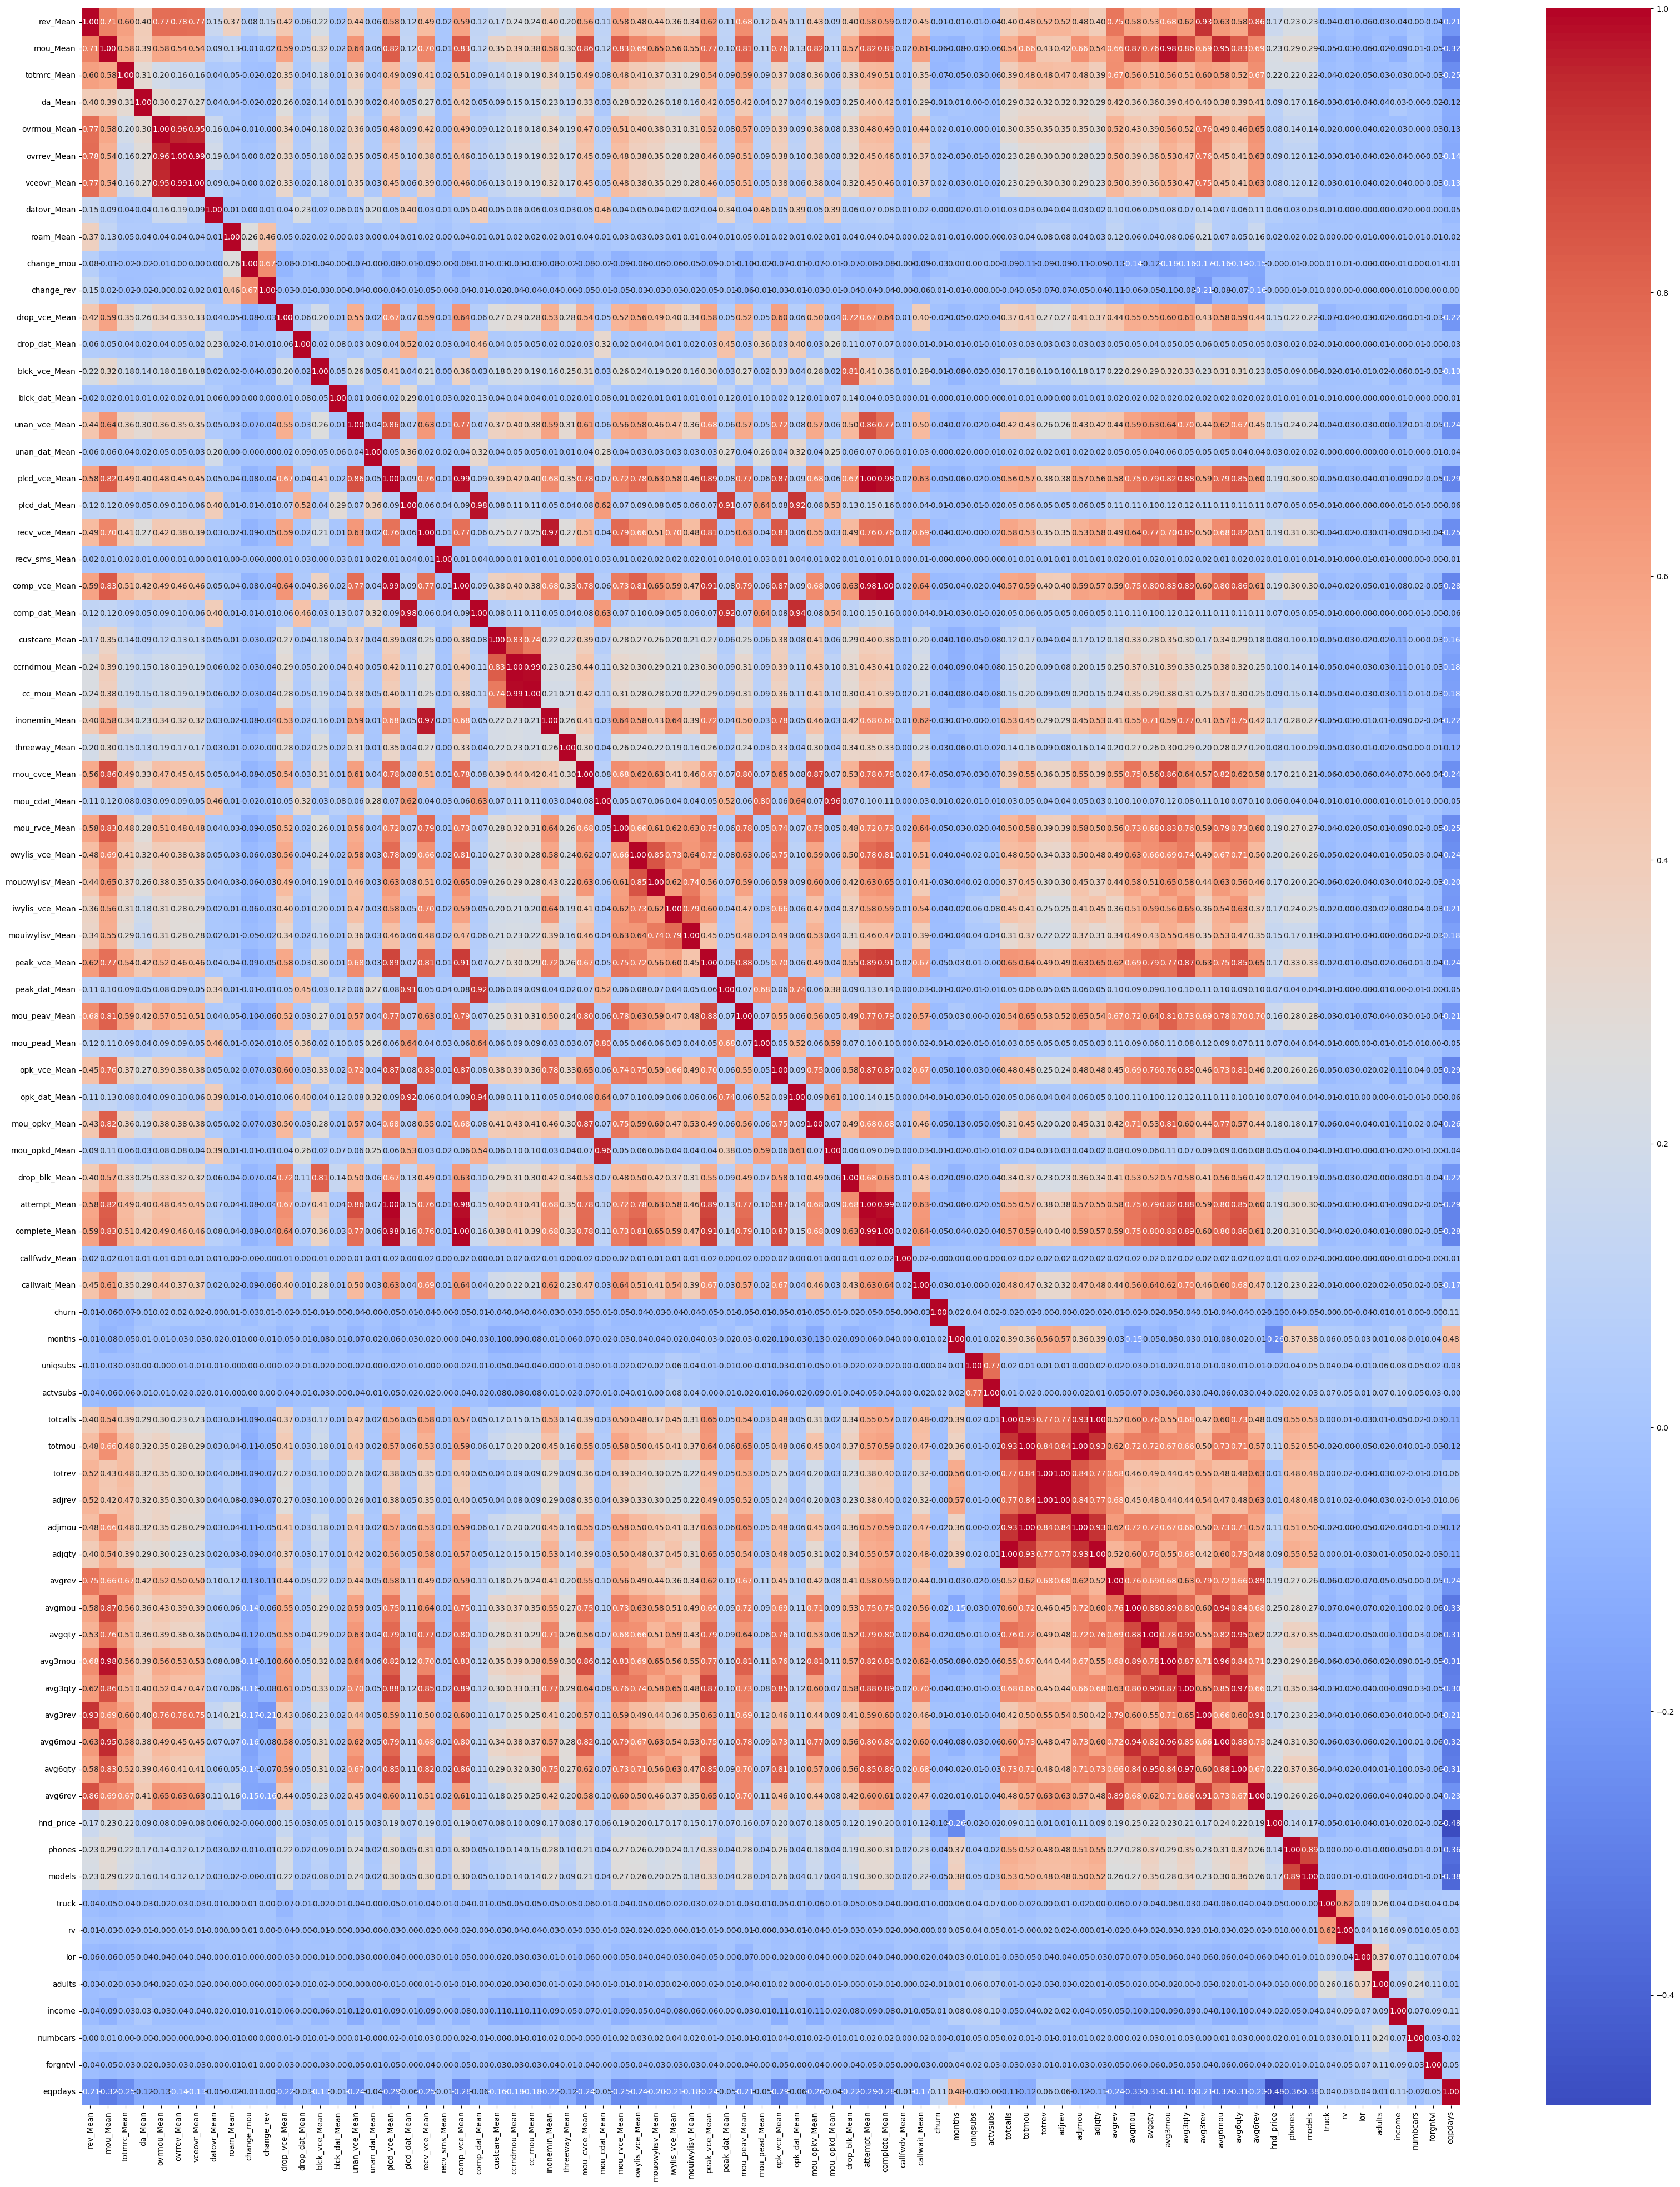

In [17]:
plt.figure(figsize=(40,49))
sns.heatmap(corr_matrix,fmt=".2f",annot=True,cmap="coolwarm")
plt.show()

- We can not see anything from this heatmap because it is very big
- So I will do a mask and unstack for the correlation to present them in good df and get the names of the features

In [20]:
corr_matrix=corr_matrix.abs()

In [19]:
ones_array=np.ones(shape=corr_matrix.shape)
ones_array

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(78, 78))

In [21]:
below_active_area=np.tril(ones_array,k=-1).astype(bool)
below_active_area

array([[False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [ True,  True, False, ..., False, False, False],
       ...,
       [ True,  True,  True, ..., False, False, False],
       [ True,  True,  True, ...,  True, False, False],
       [ True,  True,  True, ...,  True,  True, False]], shape=(78, 78))

In [22]:
corr_matrix_below_area=corr_matrix.where(below_active_area)
corr_unstack=corr_matrix_below_area.unstack()
corr_unstack=corr_unstack.dropna(axis=0)
corr_unstack

rev_Mean  mou_Mean       0.706029
          totmrc_Mean    0.602148
          da_Mean        0.403806
          ovrmou_Mean    0.772117
          ovrrev_Mean    0.776647
                           ...   
income    forgntvl       0.088237
          eqpdays        0.105680
numbcars  forgntvl       0.025110
          eqpdays        0.019281
forgntvl  eqpdays        0.046153
Length: 3003, dtype: float64

In [23]:
corr_unstack=corr_unstack.sort_values(ascending=False)
corr_unstack

totcalls       adjqty           0.999798
totmou         adjmou           0.999747
totrev         adjrev           0.998492
plcd_vce_Mean  attempt_Mean     0.998398
comp_vce_Mean  complete_Mean    0.997706
                                  ...   
opk_dat_Mean   forgntvl         0.000094
vceovr_Mean    numbcars         0.000074
change_rev     actvsubs         0.000053
recv_sms_Mean  callfwdv_Mean    0.000010
peak_dat_Mean  income           0.000008
Length: 3003, dtype: float64

- Now we can detect there are features has high correlation up to 99%

In [24]:
corr_unstack=corr_unstack.reset_index()

- Now there is good presentation in df

In [25]:
corr_unstack.columns=["First","Second","Ratio"]

In [26]:
corr_unstack

,First,Second,Ratio
0,totcalls,adjqty,0.999798
1,totmou,adjmou,0.999747
2,totrev,adjrev,0.998492
3,plcd_vce_Mean,attempt_Mean,0.998398
4,comp_vce_Mean,complete_Mean,0.997706
...,...,...,...
2998,opk_dat_Mean,forgntvl,0.000094
2999,vceovr_Mean,numbcars,0.000074
3000,change_rev,actvsubs,0.000053
3001,recv_sms_Mean,callfwdv_Mean,0.000010


In [28]:
high_corr=corr_unstack[corr_unstack["Ratio"]>=0.80]
high_corr

,First,Second,Ratio
0,totcalls,adjqty,0.999798
1,totmou,adjmou,0.999747
2,totrev,adjrev,0.998492
3,plcd_vce_Mean,attempt_Mean,0.998398
4,comp_vce_Mean,complete_Mean,0.997706
...,...,...,...
99,comp_vce_Mean,owylis_vce_Mean,0.810337
100,owylis_vce_Mean,complete_Mean,0.809994
101,mou_cvce_Mean,mou_peav_Mean,0.803652
102,complete_Mean,avg6mou,0.803485


- There are most important columns I will use them so I will delet the crosbonding feature for it

In [31]:
important_features_list = [
    'eqpdays',
    'change_mou',
    'change_rev',
    'months',
    'mou_Mean',
    'avgqty',
    'rev_Mean',
    'totrev',
    'totcalls'
]

In [30]:
names_cols_high_corr=list(high_corr["Second"].unique())
names_cols_high_corr

['adjqty',
 'adjmou',
 'adjrev',
 'attempt_Mean',
 'complete_Mean',
 'vceovr_Mean',
 'cc_mou_Mean',
 'comp_vce_Mean',
 'comp_dat_Mean',
 'avg3mou',
 'avg6qty',
 'inonemin_Mean',
 'avg6mou',
 'mou_opkd_Mean',
 'ovrrev_Mean',
 'opk_dat_Mean',
 'avg3rev',
 'totmou',
 'peak_dat_Mean',
 'avg6rev',
 'peak_vce_Mean',
 'avg3qty',
 'models',
 'avgqty',
 'mou_peav_Mean',
 'opk_vce_Mean',
 'mou_opkv_Mean',
 'avgmou',
 'mou_cvce_Mean',
 'plcd_vce_Mean',
 'mouowylisv_Mean',
 'totrev',
 'mou_rvce_Mean',
 'ccrndmou_Mean',
 'drop_blk_Mean',
 'owylis_vce_Mean']

In [32]:
one_full_data_phase=full_data.copy()
for x in names_cols_high_corr:
    if x not in important_features_list:
        one_full_data_phase.drop(x,axis=1,inplace=True)
        

In [33]:
one_full_data_phase.shape

(100000, 65)

- make sure again if there is not high corr

In [35]:
num_cols_corr_phase1=one_full_data_phase.select_dtypes(include="number").columns

In [36]:
corr_matrix_phase1=one_full_data_phase.loc[:,num_cols_corr_phase1].corr()
corr_matrix_phase1=corr_matrix_phase1.abs()
ones_array_phase1=np.ones(corr_matrix_phase1.shape)
mask_phase1=np.tril(ones_array_phase1,k=-1).astype(bool)
corr_matrix_phase1=corr_matrix_phase1.where(mask_phase1)
corr_unstack_phase1=corr_matrix_phase1.unstack()
corr_unstack_phase1=corr_unstack_phase1.dropna(axis=0)
corr_unstack_phase1.sort_values(ascending=False)


mou_cdat_Mean    mou_pead_Mean      0.797174
iwylis_vce_Mean  mouiwylisv_Mean    0.785465
uniqsubs         actvsubs           0.774229
recv_vce_Mean    avgqty             0.773506
rev_Mean         ovrmou_Mean        0.772117
                                      ...   
ovrmou_Mean      uniqsubs           0.000207
change_rev       numbcars           0.000202
change_mou       uniqsubs           0.000185
change_rev       actvsubs           0.000053
recv_sms_Mean    callfwdv_Mean      0.000010
Length: 946, dtype: float64

- it is done now

---

- let's see the nan values of the data

In [38]:
nan_phase_one=one_full_data_phase.isna().sum().sort_values(ascending=False)
nan_phase_one[nan_phase_one>0]

numbcars            49366
dwllsize            38308
HHstatin            37923
ownrent             33706
dwlltype            31909
lor                 30190
income              25436
adults              23019
infobase            22079
hnd_webcap          10189
prizm_social_one     7388
kid6_10              1732
ethnic               1732
marital              1732
rv                   1732
truck                1732
forgntvl             1732
kid0_2               1732
kid3_5               1732
kid16_17             1732
creditcd             1732
kid11_15             1732
change_mou            891
change_rev            891
hnd_price             847
rev_Mean              357
ovrmou_Mean           357
mou_Mean              357
totmrc_Mean           357
roam_Mean             357
da_Mean               357
datovr_Mean           357
area                   40
phones                  1
dualband                1
refurb_new              1
eqpdays                 1
dtype: int64

- Delete high nan values features

In [39]:
two_full_data_phase=one_full_data_phase.copy()

In [40]:
two_full_data_phase.drop(["numbcars","ownrent","infobase",],axis=1,inplace=True)

In [41]:
two_full_data_phase.shape

(100000, 62)

## Solve Nan Values

In [42]:
two_full_data_phase["income"]=two_full_data_phase["income"].fillna(-1)
two_full_data_phase["income"].isna().sum()

np.int64(0)

In [43]:
two_full_data_phase["hnd_webcap"].value_counts()

hnd_webcap
WCMB    75733
WC      13843
UNKW      235
Name: count, dtype: int64

In [46]:
two_full_data_phase['hnd_webcap'] = two_full_data_phase['hnd_webcap'].fillna('Missing')

In [51]:
two_full_data_phase['lor'] = two_full_data_phase['lor'].fillna(two_full_data_phase['lor'].median())

In [54]:
two_full_data_phase['adults'] = two_full_data_phase['adults'].fillna(two_full_data_phase['adults'].median())

In [55]:
two_full_data_phase['dwllsize'] = two_full_data_phase['dwllsize'].fillna('Missing')
two_full_data_phase['HHstatin'] = two_full_data_phase['HHstatin'].fillna('Missing')
two_full_data_phase['dwlltype'] = two_full_data_phase['dwlltype'].fillna('Missing')

- If the columns which has more than 30000 nan values are not important I will delete it

---

# intial model

In [60]:
cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))
num_cols_phase2=two_full_data_phase.select_dtypes(include="number")

C:\Users\Access\AppData\Local\Temp\ipykernel_5148\2408055169.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_phase2=list(two_full_data_phase.select_dtypes(include="object"))


In [57]:
for x in cat_cols_phase2:
    print(x)
    print(len(list(two_full_data_phase[x].unique())))

new_cell
3
crclscod
54
asl_flag
2
prizm_social_one
6
area
20
dualband
5
refurb_new
3
hnd_webcap
4
dwlltype
3
marital
6
HHstatin
7
dwllsize
16
ethnic
18
kid0_2
3
kid3_5
3
kid6_10
3
kid11_15
3
kid16_17
3
creditcd
3


In [59]:
from sklearn.model_selection import StratifiedShuffleSplit

In [61]:
splitter_phase2=StratifiedShuffleSplit(n_splits=1,test_size=0.2)
for train_index , test_index in splitter_phase2.split(two_full_data_phase,two_full_data_phase["churn"]):
    strat_train_phase2=two_full_data_phase.loc[train_index]
    strat_test_phase2=two_full_data_phase.loc[test_index]

In [62]:
strat_train_x_phase2=strat_train_phase2.drop("churn",axis=1)
strat_train_y_phase2=strat_train_phase2["churn"]

strat_test_x_phase2=strat_test_phase2.drop("churn",axis=1)
strat_test_y_phase2=strat_test_phase2["churn"]

In [58]:
from xgboost import XGBClassifier

In [64]:
from sklearn.metrics import classification_report

In [65]:
for col in cat_cols_phase2:
    if col in strat_train_x_phase2.columns:
        strat_train_x_phase2[col] = strat_train_x_phase2[col].astype('category')
    if col in strat_test_x_phase2.columns:
        strat_test_x_phase2[col] = strat_test_x_phase2[col].astype('category')

In [71]:
intial_model=XGBClassifier(
    n_estimators=1300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3.5,
    random_state=42,
    enable_categorical=True
)

intial_model.fit(
    strat_train_x_phase2,
    strat_train_y_phase2,
    verbose=False,
    
)


y_pred=intial_model.predict(strat_test_x_phase2)
print(classification_report(strat_test_y_phase2,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.20      0.32     10088
           1       0.54      0.94      0.68      9912

    accuracy                           0.57     20000
   macro avg       0.66      0.57      0.50     20000
weighted avg       0.66      0.57      0.50     20000



In [72]:
importance_feature=intial_model.feature_importances_
importance_feature

array([0.01456474, 0.02315766, 0.02206955, 0.01240056, 0.01927111,
       0.01252128, 0.0134905 , 0.02201803, 0.01685205, 0.01432552,
       0.00978387, 0.0126519 , 0.01112681, 0.01300501, 0.01047942,
       0.01170274, 0.01429729, 0.00982075, 0.01395139, 0.01292779,
       0.0129101 , 0.0146586 , 0.01514662, 0.01260137, 0.012191  ,
       0.01280775, 0.04049223, 0.02513017, 0.01532478, 0.01109111,
       0.01860869, 0.02342692, 0.01522551, 0.01392849, 0.01851407,
       0.0192563 , 0.01430759, 0.01840925, 0.01368462, 0.03281783,
       0.0266224 , 0.01996429, 0.02128596, 0.0116717 , 0.01299255,
       0.01940913, 0.01183723, 0.01342618, 0.01198508, 0.01419543,
       0.015541  , 0.0162422 , 0.01369222, 0.01638203, 0.01216935,
       0.01243473, 0.01346531, 0.01252817, 0.01303372, 0.02006667,
       0.04010372], dtype=float32)

In [ ]:
df_importance_feature=pd.DataFrame